# Tracks Feature Analysis

## Imports

In [13]:
from matplotlib import pyplot as plt
import openmc
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Any

import scienceplots
plt.style.use(['science', 'notebook', 'grid', 'high-vis'])  # 'high-vis' 'grid' 'notebook' 'science' 'bright'

In [14]:
tracks = openmc.Tracks("../data/track_feature/tracks.h5")
print(len(tracks))

20


In [15]:
detector_cell_id = 2  # your detector cell
multiplicities: list[float] = []  # one entry per source particle

for track in tracks:
    count = 0
    for pt in track.particle_tracks:
        for state in pt.states:
            if state['cell_id'] == detector_cell_id:
                count += 1
                break  # particle reached detector, don't double-count
    multiplicities.append(count)

Text(0.5, 1.0, 'Detector multiplicity distribution')

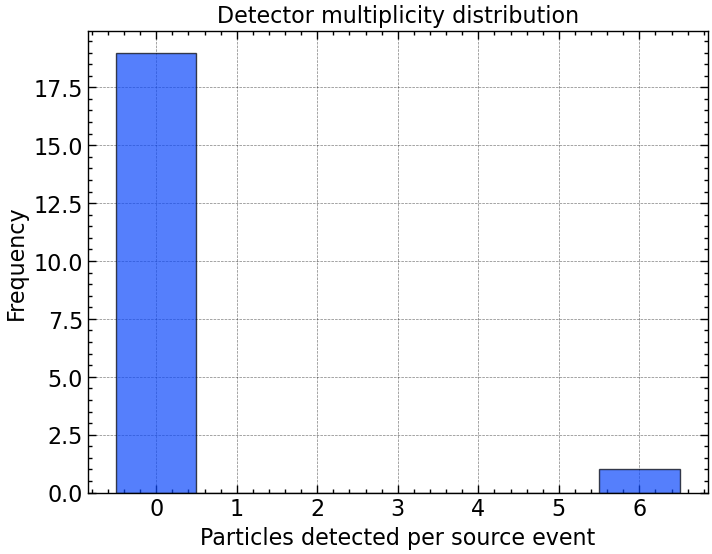

In [16]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange(-0.5, max(multiplicities) + 1.5, 1, dtype=float)
plt.figure()
plt.hist(multiplicities, bins=bins, edgecolor="black", alpha=0.7) # type: ignore
plt.xlabel("Particles detected per source event")
plt.ylabel("Frequency")
plt.title("Detector multiplicity distribution")

In [17]:
multiplicities = np.array(multiplicities)
mean = np.mean(multiplicities)
variance = np.var(multiplicities)

print(f"Mean: {mean:.3f}")
print(f"Variance: {variance:.3f}")

Mean: 0.300
Variance: 1.710


In [18]:
tracks.write_to_vtk(Path("../data/track_feature/tracks.vtp"))

<vtkmodules.vtkCommonDataModel.vtkPolyData(0x5e3925325650) at 0x7c1291e67100>